<a href="https://colab.research.google.com/github/Siya-prog/fraud-detection-ml/blob/main/FRAUD_DETECTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection using Machine Learning

In [2]:
from google.colab import files
uploaded = files.upload()

Saving creditcard.csv to creditcard (1).csv


In [3]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [20]:
df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [21]:
df = df.sample(n=50000, random_state=42)

(50000, 31)
Class
0    49917
1       83
Name: count, dtype: int64


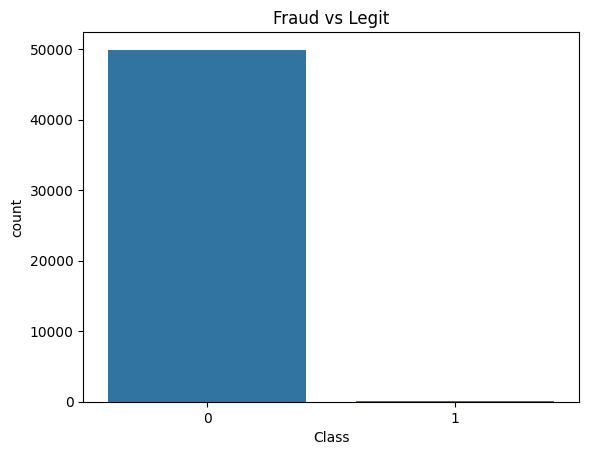

In [22]:
print(df.shape)
print(df['Class'].value_counts())

sns.countplot(x='Class', data=df)
plt.title("Fraud vs Legit")
plt.show()

In [23]:
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])

df = df.drop(['Time', 'Amount'], axis=1)

X = df.drop('Class', axis=1)
y = df['Class']

In [24]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print(pd.Series(y_res).value_counts())

Class
1    49917
0    49917
Name: count, dtype: int64


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)

In [26]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [27]:
dt = DecisionTreeClassifier(max_depth=10)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [28]:
rf = RandomForestClassifier(n_estimators=50, max_depth=10)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [29]:
xgb = XGBClassifier(n_estimators=50, max_depth=5, learning_rate=0.1)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [30]:
def evaluate(y_test, y_pred, name):
    print(f"\n{name}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_pred))

In [31]:
evaluate(y_test, y_pred_lr, "Logistic Regression")
evaluate(y_test, y_pred_dt, "Decision Tree")
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_xgb, "XGBoost")


Logistic Regression
[[9781  283]
 [ 461 9442]]
              precision    recall  f1-score   support

           0       0.95      0.97      0.96     10064
           1       0.97      0.95      0.96      9903

    accuracy                           0.96     19967
   macro avg       0.96      0.96      0.96     19967
weighted avg       0.96      0.96      0.96     19967

ROC-AUC: 0.9626642090840775

Decision Tree
[[10001    63]
 [   13  9890]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     10064
           1       0.99      1.00      1.00      9903

    accuracy                           1.00     19967
   macro avg       1.00      1.00      1.00     19967
weighted avg       1.00      1.00      1.00     19967

ROC-AUC: 0.9962136650389543

Random Forest
[[10058     6]
 [    0  9903]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10064
           1       1.00      1.00      1.

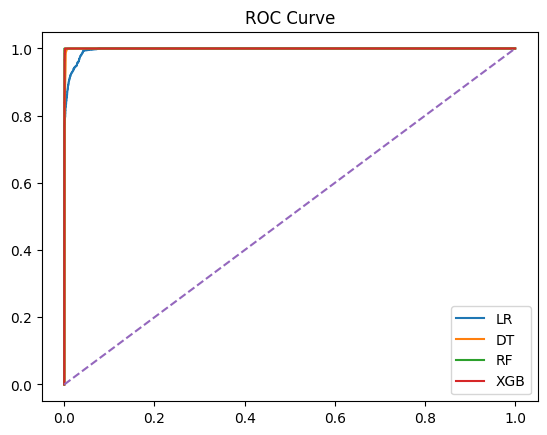

In [32]:
for model, name in [(lr,"LR"), (dt,"DT"), (rf,"RF"), (xgb,"XGB")]:
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

In [33]:
iso = IsolationForest(contamination=0.01)

y_pred_iso = iso.fit_predict(X)

y_pred_iso = [1 if x == -1 else 0 for x in y_pred_iso]

print(confusion_matrix(y, y_pred_iso))
print(classification_report(y, y_pred_iso))

[[49466   451]
 [   35    48]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     49917
           1       0.10      0.58      0.16        83

    accuracy                           0.99     50000
   macro avg       0.55      0.78      0.58     50000
weighted avg       1.00      0.99      0.99     50000



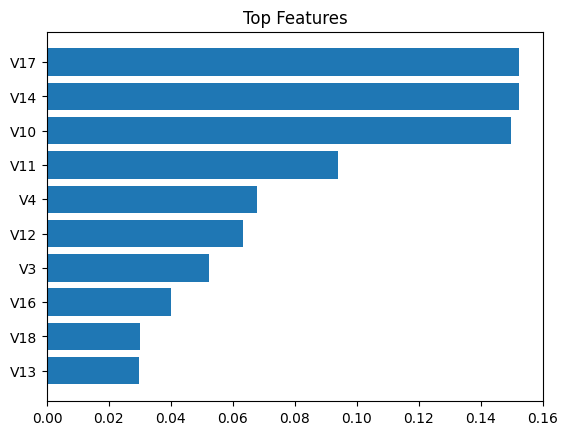

In [34]:
import numpy as np

importances = rf.feature_importances_
features = X.columns

indices = np.argsort(importances)[-10:]

plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.title("Top Features")
plt.show()

In [35]:
def predict_transaction(sample):
    sample = np.array(sample).reshape(1, -1)
    pred = rf.predict(sample)

    if pred[0] == 1:
        return "🚨 Fraud"
    else:
        return "✅ Legit"

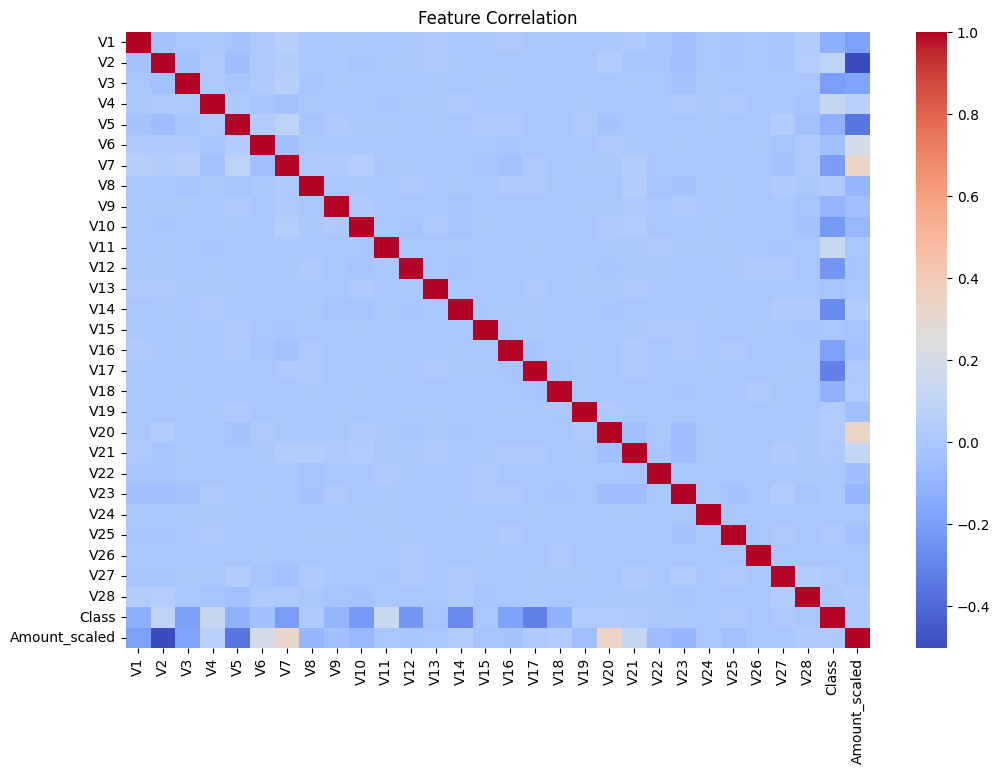

In [36]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()